In [1]:
import IPython.display as ipd

import os, sys
current_path = os.getcwd()
path_parts = current_path.split(os.sep)
idx = path_parts.index("occupancy-estimation")
homepath = os.sep.join(path_parts[:idx + 1]) +"/"
sys.path.insert(0,homepath)

%load_ext autoreload 
%autoreload 2


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import reciprocalspaceship as rs
import pandas as pd
from meteor import rsmap
from meteor.utils import cut_resolution

from logger import setup_logger

logger = setup_logger()

In [3]:
from configuration import load_homepath
from configuration import get_file_config, get_file_config_diff_only

# config = apply_config_myoglobin_general("0.1ps")

In [5]:
from pathlib import Path
from dataset_configs import apply_config_myoglobin_general
# Path()
if False:
    config = apply_config_myoglobin_general(0)
    for f in Path(config["general"]["output_folder"]).iterdir():
        loc = f / "diffmap_23.0_vanilla_1000.mtz"
        # loc = f / "diffmap_23.0_kweighted_1000.mtz"
        if loc.is_file():
            print(f"Removing {loc}")
            loc.unlink()


In [ ]:
from configuration import minimal_masking_config
from processing import get_maps, prepare_maps
from masking import make_inclusion_mask
import copy 
from estimation import plot_extrapolation_estimate_new

config = apply_config_myoglobin_general("0.1ps")

unscaled_dark, unscaled_triggered = get_maps(config)
config["map_processing"]["diffmap_v2_correction"]=False
config["map_processing"]["diffmap_mean_correction"]=False
diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)

diffmap_np = diffmap.to_3d_numpy_map(map_sampling=config["general"]["map_sampling"])
logger.warning(
    f"Diffmap Mean: {diffmap_np.mean():.6f}, Std: {diffmap_np.std():.6f}"
)
config_nse=copy.deepcopy(config)

config_nse["masking"] = minimal_masking_config()
inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)


config["plot"]["set_ylim"] = ((0, 1.5))
# plot_extrapolation_estimate(diffmap, map_dark, inclusion_mask, config)
plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask, config)

2026-03-14 12:54:53,761: logger: INFO: Imposing high_resolution_limit: 2.3 (processing.py:69)
2026-03-14 12:54:54,440: logger: INFO: No recent preprocessed diffmap found at /Users/sbielfel/Nextcloud2/time_resolved/tmp/diffmap_data/myo_0.1ps/diffmap_23.0_tv_1001.mtz, calculating diffmap... (processing.py:229)
2026-03-14 12:54:54,440: logger: INFO: this is calculate_again True (processing.py:125)
2026-03-14 12:54:54,442: logger: WARNING: Loaded meta from file: (processing.py:139)
2026-03-14 12:54:54,442: logger: INFO: loading: 0.2, tv_weight: 0.05248500898726734, only_kweighted: False (processing.py:147)


2026-03-14 12:54:54 [info     ] scaling: native --> calculated weight_using_uncertainties=True
2026-03-14 12:54:54 [info     ] scaling: derivative --> calculated weight_using_uncertainties=True
2026-03-14 12:54:54 [info     ] Computing difference map.     
2026-03-14 12:54:54 [info     ]   using fixed                  kparameter=0.2
2026-03-14 12:54:54 [info     ] TV denoising with fixed weight weight=0.05248500898726734
2026-03-14 12:54:54 [info     ] Map TV-denoised with fixed weight final_negentropy=2.53e-01 initial_negentropy=8.13e-04 weight=0.05248500898726734


2026-03-14 12:54:54,710: logger: INFO: diffmap has uncertainties: True (processing.py:189)
2026-03-14 12:54:54,714: logger: INFO: Diffmap std: 0.023 (processing.py:610)
2026-03-14 12:54:54,715: logger: INFO: diffmap larger voxel count: 0.17577473958333334 (processing.py:611)
2026-03-14 12:54:54,725: logger: INFO: ignore_mask voxel count: 0.2712890625 (processing.py:279)
2026-03-14 12:54:54,726: logger: INFO: Shift value 0.32311 corresponds to zero frequency 20201.459 (processing.py:293)
2026-03-14 12:54:54,736: logger: INFO: calculating autoshift for triggered map... with extra mask (processing.py:617)
2026-03-14 12:54:54,746: logger: INFO: ignore_mask voxel count: 0.39572265625 (processing.py:279)
2026-03-14 12:54:54,747: logger: INFO: Shift value 0.32866 corresponds to zero frequency 20548.561 (processing.py:293)
2026-03-14 12:54:54,757: logger: INFO: calculating autoshift for triggered map... done (processing.py:621)
2026-03-14 12:54:54,758: logger: INFO: Loading preprocessed maps f

2026-03-14 12:54:58,805: logger: WARNING: Mean of diffmap_np: 4.675611762650078e-06, Mean of map_dark_np: 0.3231068551540375 (estimation.py:642)


(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='Difference Map $-\\Delta \\rho$ (standard deviations)', ylabel='Extrapolation factor $ \\chi^{-1} = -\\Delta\\rho/\\rho_{0}$'>)

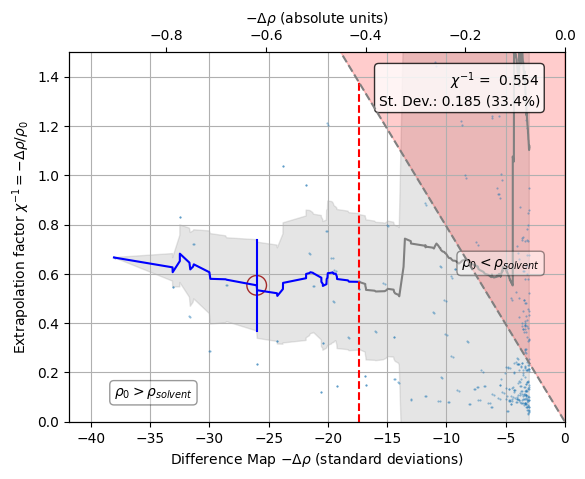

{'map_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cmv.mtz', 'map_triggered': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cn4.mtz', 'pdb_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5CMV.pdb', 'columns_dark': {'amplitude_column': 'F', 'phase_column': 'PHIC', 'uncertainty_column': 'SIGF', 'ints_column': 'IMEAN', 'int_uncertainty_column': 'SIGIMEAN'}, 'columns_triggered': {'amplitude_column': 'F', 'phase_column': 'PHIC', 'uncertainty_column': 'SIGF', 'ints_column': 'IMEAN', 'int_uncertainty_column': 'SIGIMEAN'}, 'impose_dark_phases': True, 'columns_are_ints': True}
{'map_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cmv.mtz', 'map_triggered': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cn5.mtz', 'pdb_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5CMV.pdb', 'columns_dark': {'amplitude_column': 'F', 'phase_column': 'PHIC', 'uncertainty_column': 'SIGF', 'ints_column': 'IMEAN', 'int_uncert

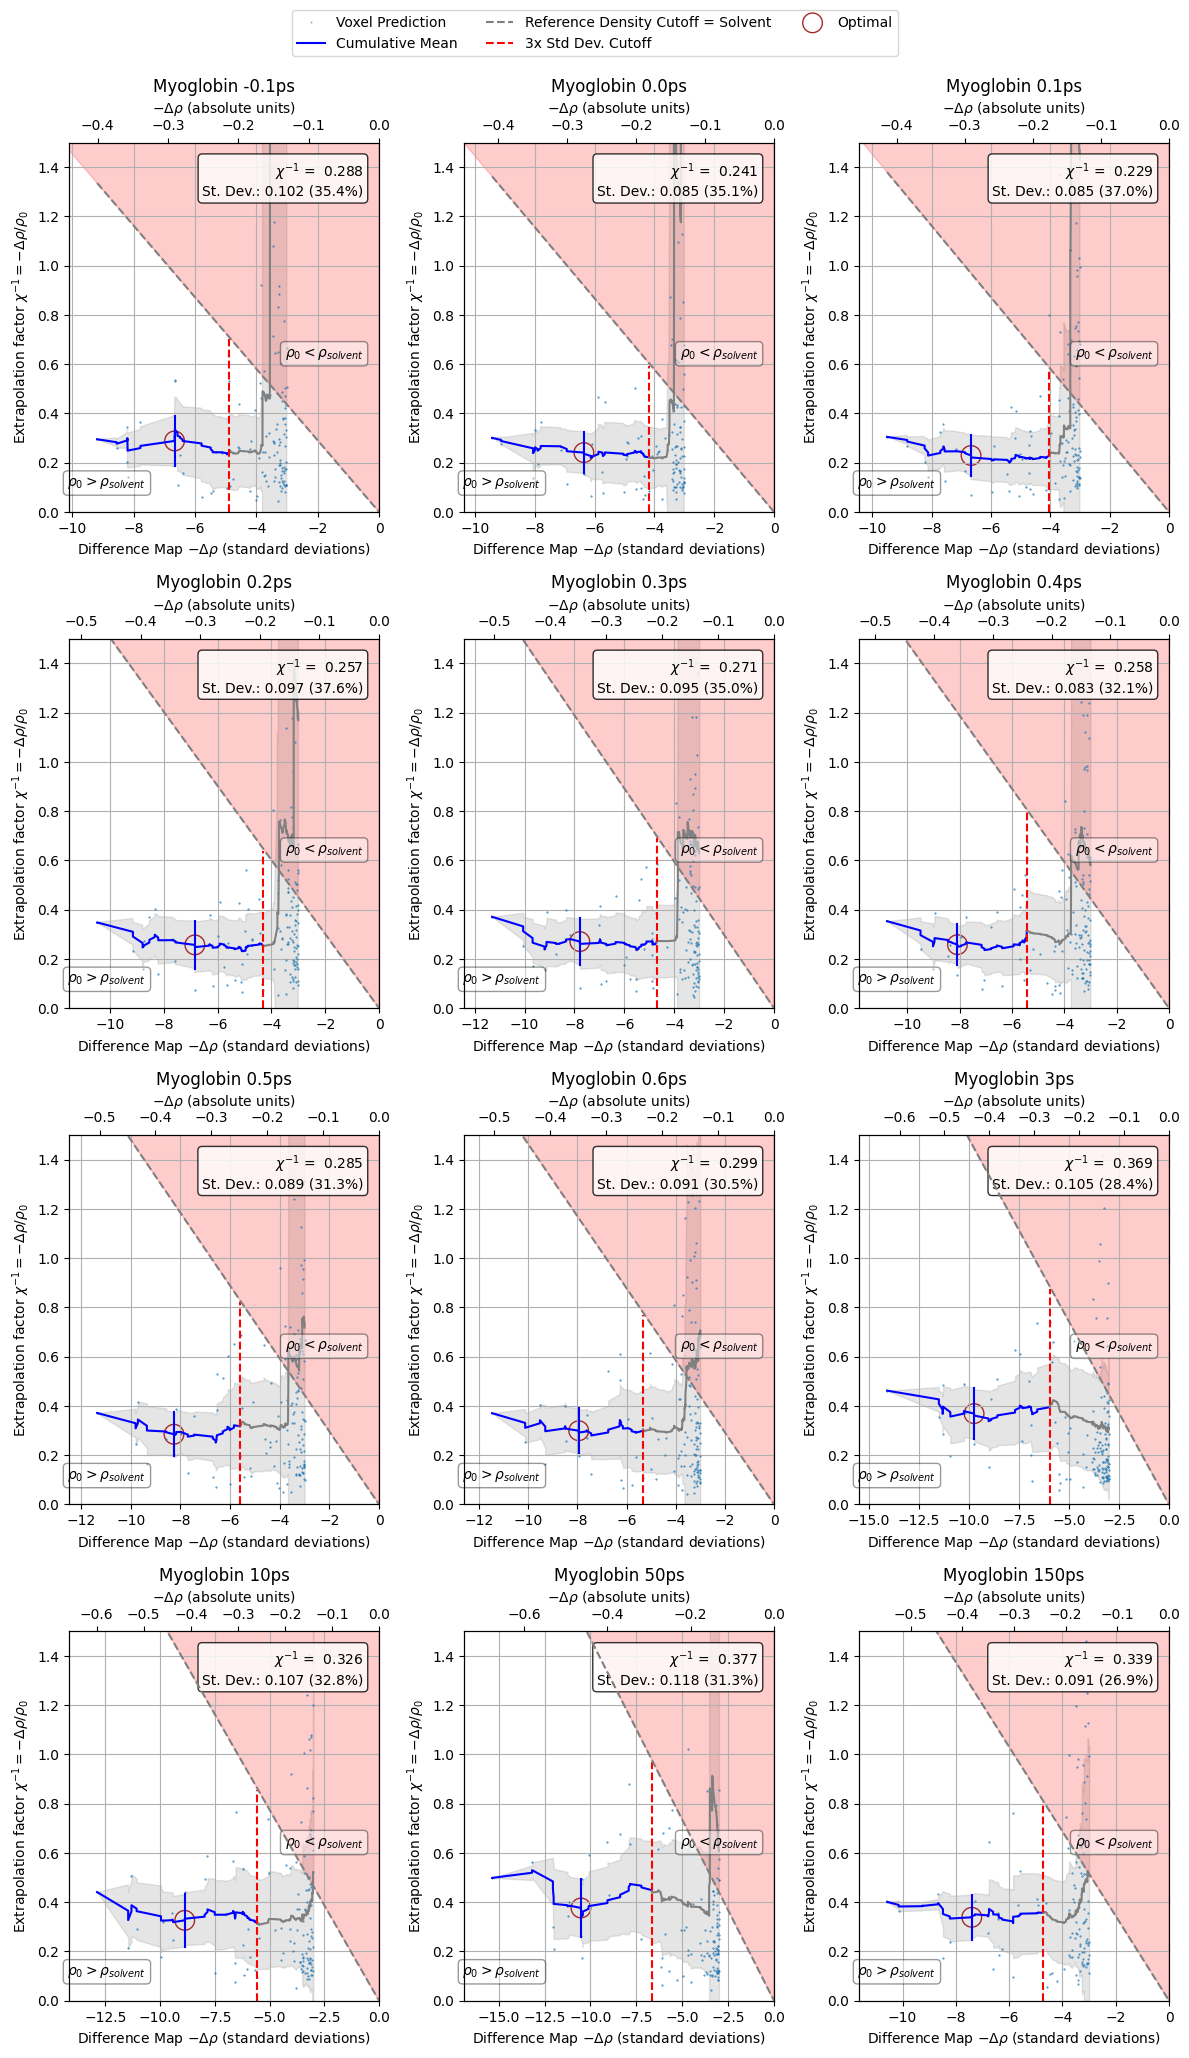

In [9]:
from masking import make_inclusion_mask
from estimation import plot_extrapolation_estimate_new
from logger import setup_logger
import logging 
logger = setup_logger(log_level=logging.ERROR)

# 1. Create the main figure
fig,axs = plt.subplots(4,3, figsize=(12, 20), tight_layout=True)

for i, ax in enumerate(axs.flatten()):
    # if not i: continue

    config = apply_config_myoglobin_general(i)
    print(config["input_files"])
    ax.set_title(config["general"]["name_human"])
    config["masking"]["dark_size_threshold"] = 0

    unscaled_dark, unscaled_triggered = get_maps(config)
    config["map_processing"]["diffmap_type"]="vanilla"
    # config["map_processing"]["diffmap_type"]="otehr"
    config["map_processing"]["diffmap_v2_correction"]=False
    config["map_processing"]["diffmap_mean_correction"]=False
    diffmap, map_dark, _ = prepare_maps(unscaled_dark, unscaled_triggered, config)


    config_nse["masking"] = minimal_masking_config()
    inclusion_mask = make_inclusion_mask(diffmap, map_dark, config_nse)
    config["plot"]["set_ylim"] = ((0, 1.5))

    plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask, config, ax)


handles, labels = axs[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, 
    loc='upper center', 
    ncol=3,             # Adjust ncol to spread them horizontally
    bbox_to_anchor=(0.5, 1.03)) # Moves it above the subplots

# 3. Use tight_layout but leave room at the top for the legend
plt.tight_layout()


In [116]:
config_nse["masking"]

{'sigma': 3,
 'min_blob_size': 0.3,
 'blocking_radius': 0.1,
 'blocking_percentile': 95,
 'exclude_solvent': False,
 'dark_size_threshold': 0.0,
 'exclude_large_occupancy_outliers': False}

In [117]:
print(config["input_files"])
print(config["masking"])

{'map_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cmv.mtz', 'map_triggered': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5cn4.mtz', 'pdb_dark': '/Users/sbielfel/Nextcloud2/time_resolved/data/myoglobin/5CMV.pdb', 'columns_dark': {'amplitude_column': 'F', 'phase_column': 'PHIC', 'uncertainty_column': 'SIGF'}, 'columns_triggered': {'amplitude_column': 'F', 'phase_column': 'PHIC', 'uncertainty_column': 'SIGF'}, 'impose_dark_phases': True, 'columns_are_ints': True}
{'sigma': 3, 'min_blob_size': 3, 'blocking_radius': 1.5, 'blocking_percentile': 95, 'exclude_solvent': True, 'dark_size_threshold': 0, 'exclude_positive_diffmap': True, 'exclude_large_occupancy_outliers': False}


In [100]:
# from configuration import load_figurepath
# from masking import make_inclusion_mask
# from estimation import plot_extrapolation_estimate_new
# from configuration import minimal_masking_config
# import copy

# # 1. Create the main figure
# fig,axs = plt.subplots(4,2, figsize=(12, 20), tight_layout=True)
# map_dark_base_false = copy.deepcopy(map_dark_base)
# # print(map_dark_base_false.loc[(0,0,0)])
# # map_dark_base_false.loc[(0,0,0)] *= 0.8
# # 2. Define the 2x2 outer grid
# for i, ax in enumerate(axs.flatten()):
#     if i == 1:
#         continue

#     config = apply_config_B12_general(i)
#     config["masking"]["exclude_large_occupancy_outliers"] = False
#     config["masking"]["dark_size_threshold"] = 0
    
#     map_dark, diffmap = get_maps_diff(config, map_dark=map_dark_base_false)
#     config_nse = copy.deepcopy(config)
#     # config_nse["masking"] = minimal_masking_config()
#     map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
#     diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
#     print(f"Config {i}: map_dark_np shape: {map_dark_np.shape}, diffmap_np shape: {diffmap_np.shape}")
#     print(f"Config {i}: map_dark unit cell: {map_dark.cell}, diffmap unit cell: {diffmap.cell}")
#     print(f"Config {i}: map_dark space group: {map_dark.spacegroup}, diffmap space group: {diffmap.spacegroup}")
#     inclusion_mask_nse = make_inclusion_mask(diffmap, map_dark, config_nse)

#     plot_extrapolation_estimate_new(diffmap, map_dark, inclusion_mask_nse, config, ax)
#     ax.set_title(config["general"]["name_human"])
# # axs[0].set_xlim(0,1)
# # axs[0].set_ylim(0,0.81)

<unknown>:562: SyntaxWarning: invalid escape sequence '\c'
<unknown>:562: SyntaxWarning: invalid escape sequence '\c'
